# Benchmark Analysis (Starter Matrix)

This notebook reads consolidated outputs generated by `scripts/loadgen/aggregate_starter_matrix.py`.

In [2]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ANALYSIS_DIR = Path('../results/loadgen/analysis/starter_matrix_2026-02-20')
METHOD_AGG = ANALYSIS_DIR / 'starter_matrix_method_agg.csv'
TERMINAL_AGG = ANALYSIS_DIR / 'starter_matrix_terminal_agg.csv'
AB_DELTA = ANALYSIS_DIR / 'starter_matrix_ab_delta_primary.csv'
SUMMARY_MD = ANALYSIS_DIR / 'starter_matrix_summary.md'
PLOT_LATENCY = ANALYSIS_DIR / 'plots' / 'ab_p95_latency_primary_methods.png'
PLOT_TERMINAL = ANALYSIS_DIR / 'plots' / 'ab_terminal_throughput_by_scenario.png'

for p in [METHOD_AGG, TERMINAL_AGG, AB_DELTA, SUMMARY_MD, PLOT_LATENCY, PLOT_TERMINAL]:
    print(f'{p}:', 'present' if p.exists() else 'missing')


../results/loadgen/analysis/starter_matrix_2026-02-20/starter_matrix_method_agg.csv: present
../results/loadgen/analysis/starter_matrix_2026-02-20/starter_matrix_terminal_agg.csv: present
../results/loadgen/analysis/starter_matrix_2026-02-20/starter_matrix_ab_delta_primary.csv: present
../results/loadgen/analysis/starter_matrix_2026-02-20/starter_matrix_summary.md: present
../results/loadgen/analysis/starter_matrix_2026-02-20/plots/ab_p95_latency_primary_methods.png: present
../results/loadgen/analysis/starter_matrix_2026-02-20/plots/ab_terminal_throughput_by_scenario.png: present


## Method Aggregates

In [3]:
method_df = pd.read_csv(METHOD_AGG)
method_df.head(20)


,scenario_id,design,method,run_count,throughput_rps_mean,throughput_rps_std,latency_p95_ms_mean,latency_p95_ms_std,grpc_non_ok_rate_mean,grpc_non_ok_rate_std
0,design_a_s_low_submit_heavy,A_microservices,CancelJob,3,0.25,0.0,11.282667,1.381711,0.0,0.0
1,design_a_s_low_submit_heavy,A_microservices,GetJobResult,3,0.75,0.0,13.015667,2.253050,0.0,0.0
2,design_a_s_low_submit_heavy,A_microservices,GetJobStatus,3,1.00,0.0,11.232333,1.402370,0.0,0.0
3,design_a_s_low_submit_heavy,A_microservices,ListJobs,3,0.00,0.0,0.000000,0.000000,1.0,0.0
4,design_a_s_low_submit_heavy,A_microservices,SubmitJob,3,3.00,0.0,13.992667,2.213097,0.0,0.0
5,design_b_s_low_submit_heavy,B_monolith,CancelJob,3,0.25,0.0,13.996667,4.064103,0.0,0.0
6,design_b_s_low_submit_heavy,B_monolith,GetJobResult,3,0.75,0.0,14.880000,1.289799,0.0,0.0
7,design_b_s_low_submit_heavy,B_monolith,GetJobStatus,3,1.00,0.0,11.899333,1.687463,0.0,0.0
8,design_b_s_low_submit_heavy,B_monolith,ListJobs,3,0.00,0.0,0.000000,0.000000,1.0,0.0
9,design_b_s_low_submit_heavy,B_monolith,SubmitJob,3,3.00,0.0,15.211333,1.842811,0.0,0.0


## A/B Deltas (Primary Methods)

In [4]:
delta_df = pd.read_csv(AB_DELTA)
delta_df.head(30)


,scenario_id,method,a_throughput_rps_mean,b_throughput_rps_mean,throughput_delta_b_minus_a_rps,a_latency_p95_ms_mean,b_latency_p95_ms_mean,latency_p95_delta_b_minus_a_ms,a_non_ok_rate_mean,b_non_ok_rate_mean
0,s_low_submit_heavy,CancelJob,0.25,0.25,0.0,11.282667,13.996667,2.714000,0.0,0.0
1,s_low_submit_heavy,GetJobResult,0.75,0.75,0.0,13.015667,14.880000,1.864333,0.0,0.0
2,s_low_submit_heavy,GetJobStatus,1.00,1.00,0.0,11.232333,11.899333,0.667000,0.0,0.0
3,s_low_submit_heavy,SubmitJob,3.00,3.00,0.0,13.992667,15.211333,1.218666,0.0,0.0
4,s_low_poll_heavy,CancelJob,0.25,0.25,0.0,21.579333,9.741000,-11.838333,0.0,0.0
5,s_low_poll_heavy,GetJobResult,1.75,1.75,0.0,17.822000,13.314000,-4.508000,0.0,0.0
6,s_low_poll_heavy,GetJobStatus,2.25,2.25,0.0,13.642667,9.839000,-3.803667,0.0,0.0
7,s_low_poll_heavy,SubmitJob,0.75,0.75,0.0,19.227667,11.634667,-7.593000,0.0,0.0
8,s_low_balanced,CancelJob,0.50,0.50,0.0,12.061333,11.824000,-0.237333,0.0,0.0
9,s_low_balanced,GetJobResult,1.25,1.25,0.0,15.278333,17.018000,1.739667,0.0,0.0


## Terminal Throughput Aggregates

In [5]:
terminal_df = pd.read_csv(TERMINAL_AGG)
terminal_df.head(20)


,scenario_id,design,run_count,terminal_jobs_mean,terminal_jobs_std,terminal_throughput_rps_mean,terminal_throughput_rps_std,terminal_throughput_cv
0,design_a_s_low_submit_heavy,A_microservices,3,81.666667,2.309401,1.361111,0.038490,0.028278
1,design_b_s_low_submit_heavy,B_monolith,3,80.333333,2.081666,1.338889,0.034695,0.025913
2,design_a_s_low_poll_heavy,A_microservices,3,51.666667,0.577350,0.861111,0.009623,0.011175
3,design_b_s_low_poll_heavy,B_monolith,3,52.666667,2.309401,0.877778,0.038490,0.043850
4,design_a_s_low_balanced,A_microservices,3,85.000000,1.000000,1.416667,0.016667,0.011765
5,design_b_s_low_balanced,B_monolith,3,86.000000,1.000000,1.433333,0.016667,0.011628
6,design_a_s_medium_submit_heavy,A_microservices,3,126.333333,93.724774,2.105556,1.562079,0.741885
7,design_b_s_medium_submit_heavy,B_monolith,3,344.333333,0.577350,5.738889,0.009623,0.001677
8,design_a_s_medium_poll_heavy,A_microservices,3,108.666667,84.293139,1.811111,1.404885,0.775704
9,design_b_s_medium_poll_heavy,B_monolith,3,210.000000,4.358899,3.500000,0.072648,0.020757


## Plots

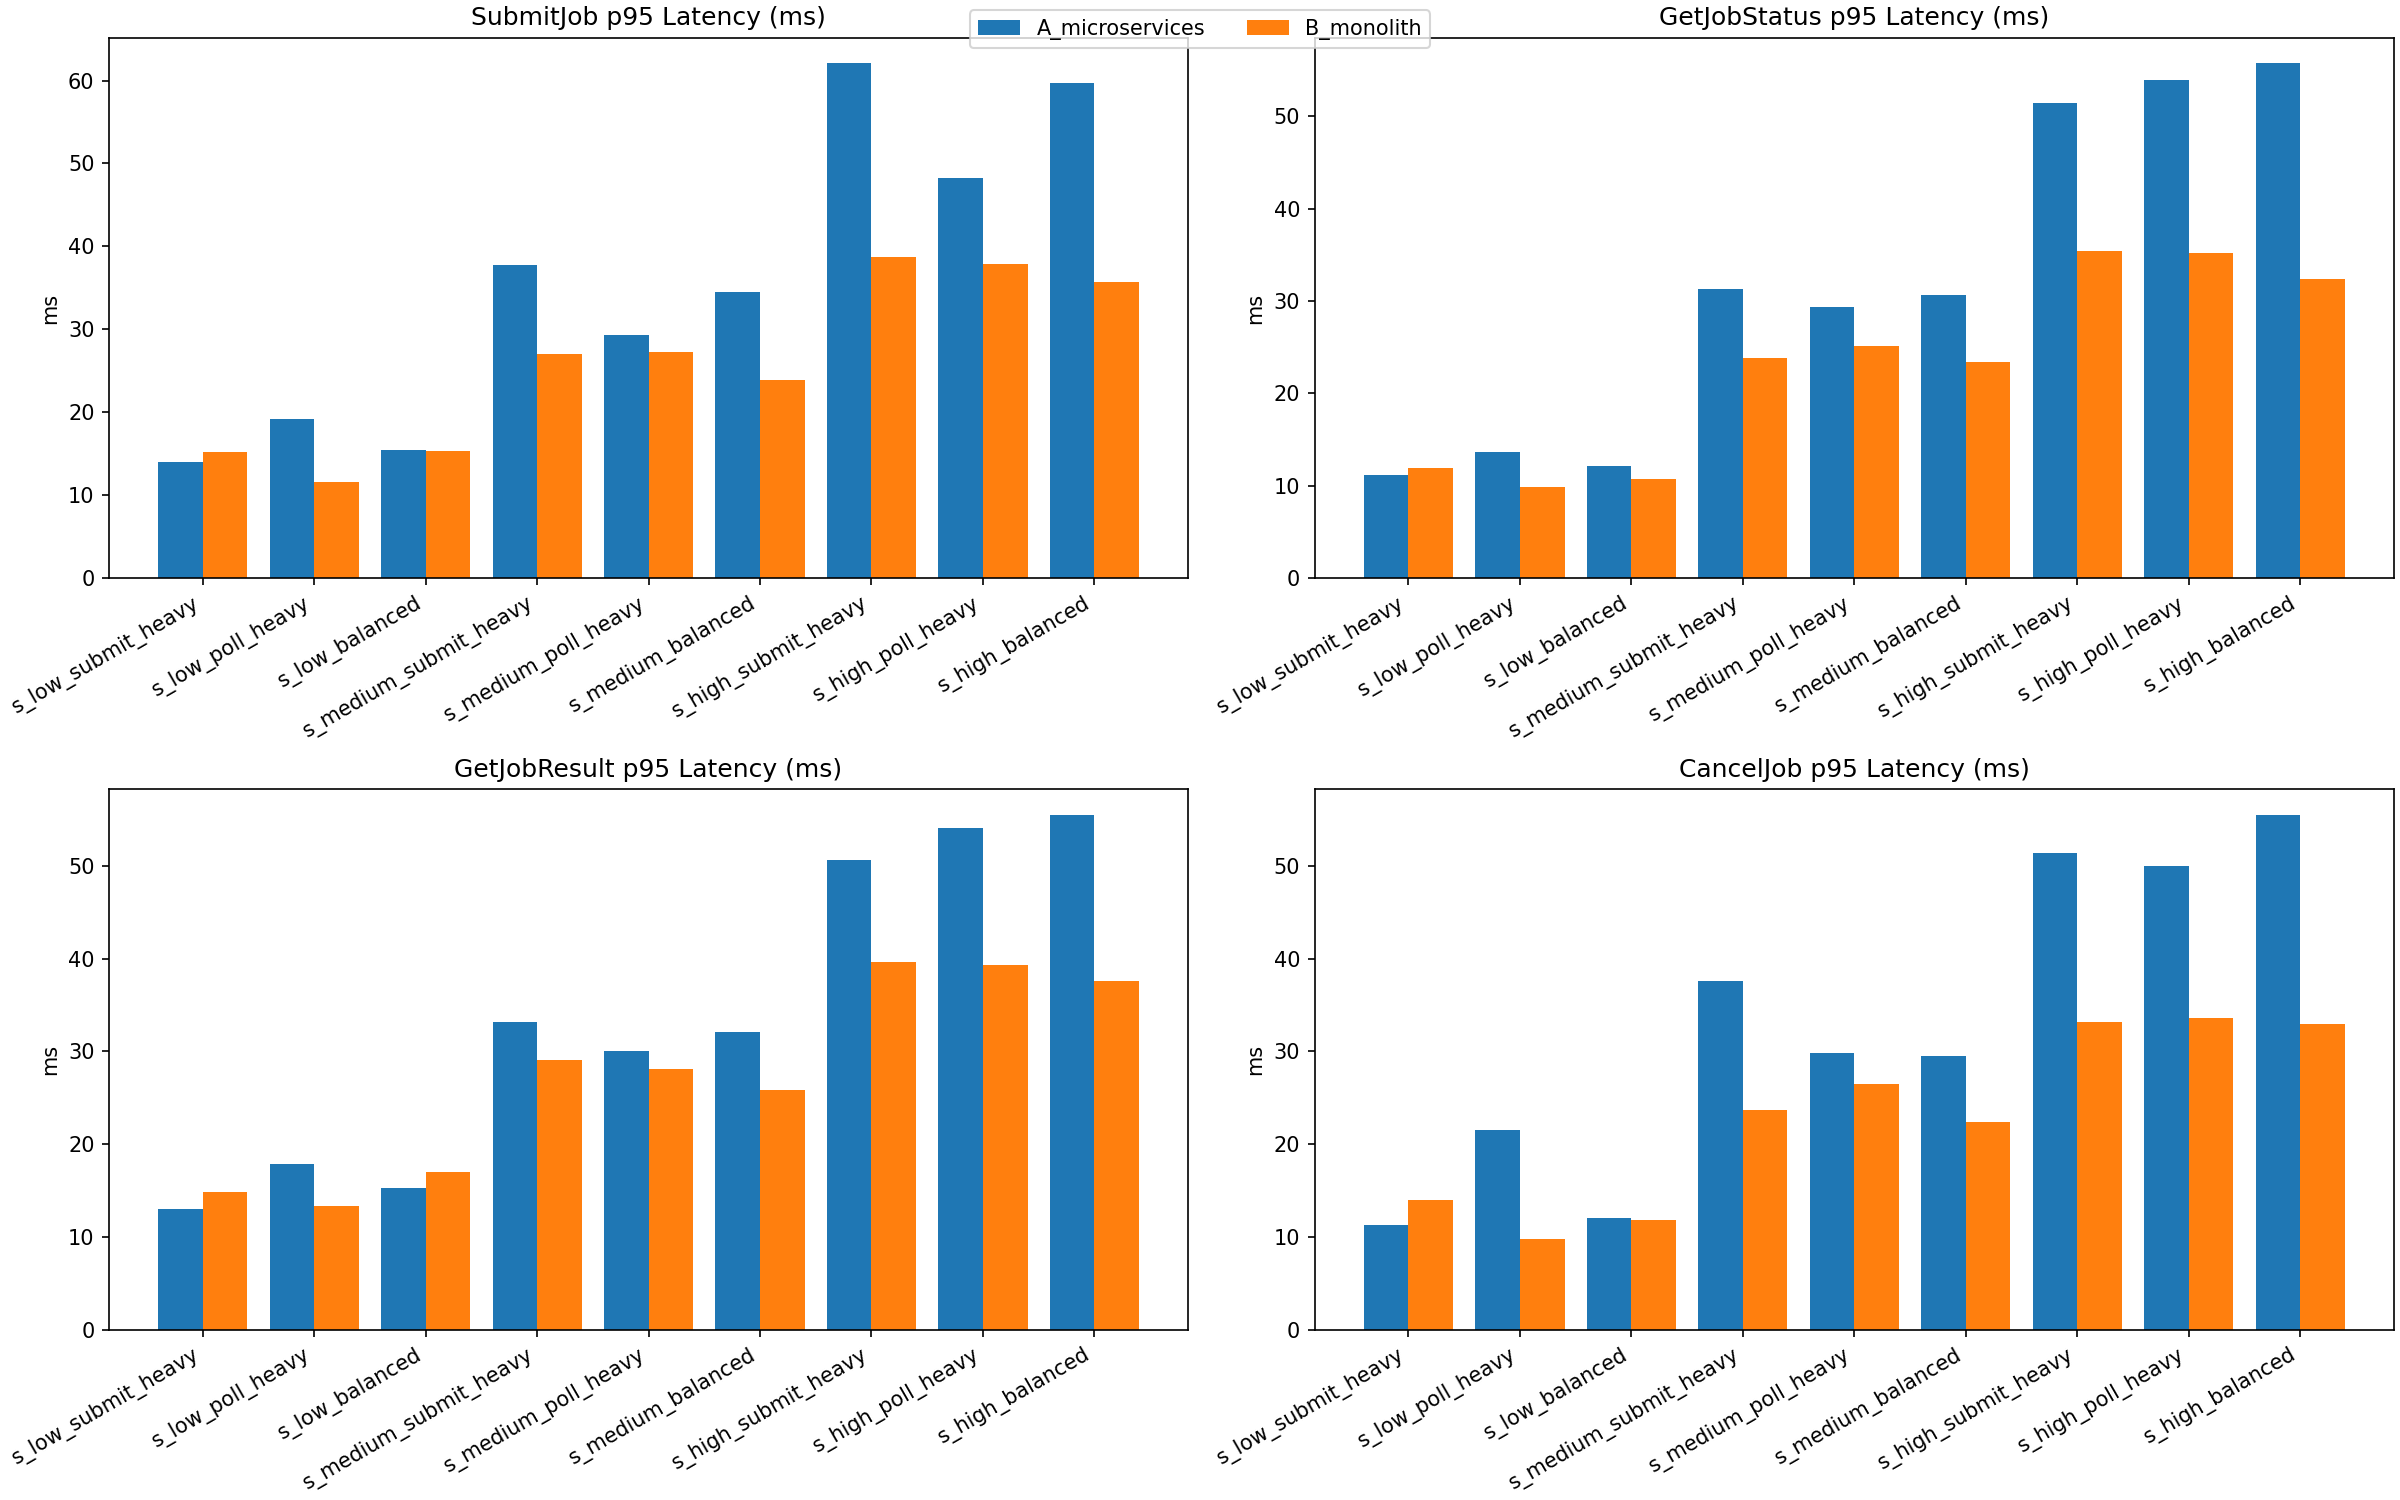

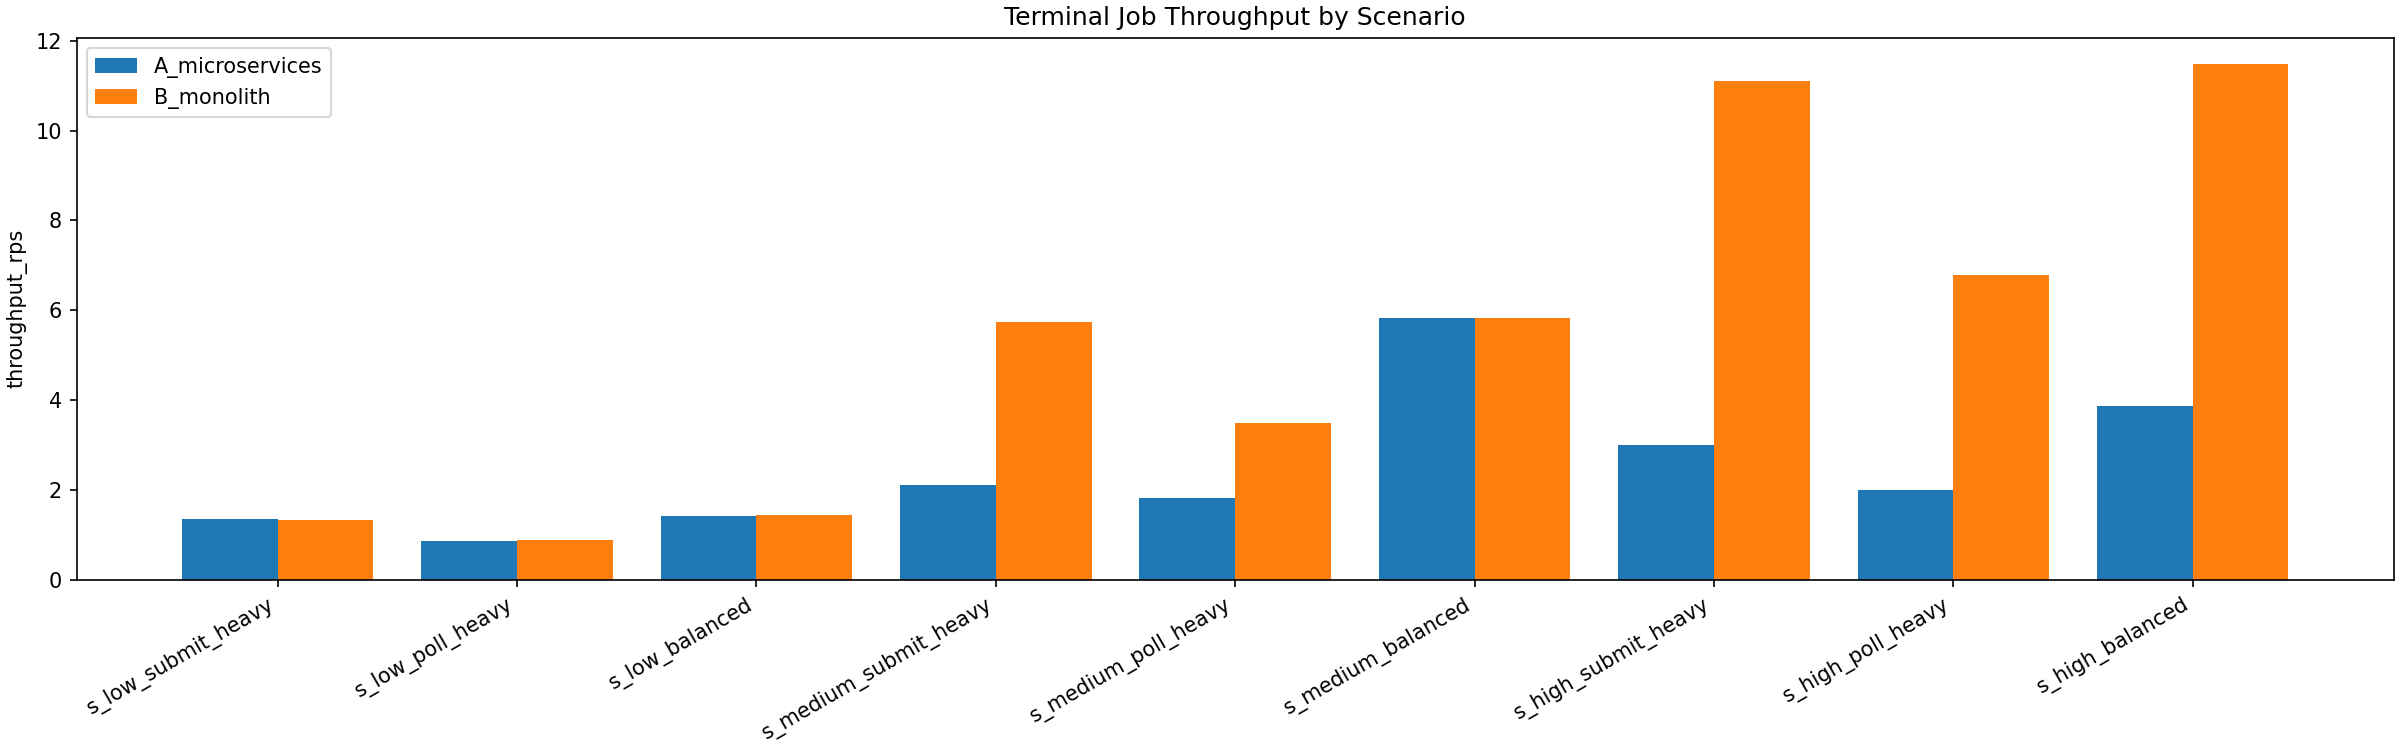

In [6]:
display(Image(filename=str(PLOT_LATENCY)))
display(Image(filename=str(PLOT_TERMINAL)))
